#Lab Sheet - 05
Name - Alok Kumar Mavi

Section - B

Roll.no. 05

CU ID - CU240251681

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from skimage import exposure

In [2]:
import os

os.listdir('/content')

['.config',
 'image2.jpg',
 'drive',
 '.ipynb_checkpoints',
 'image1.jpg',
 'sample_data']

In [3]:
image_path = '/content/image1.jpg'

img = cv2.imread(image_path)

if img is None:
    print("Error: Image could not be loaded.")
else:
    print("Image loaded successfully!")
    print("Image dimensions:", img.shape)

Image loaded successfully!
Image dimensions: (2832, 4240, 3)


In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Grayscale conversion completed.")

Grayscale conversion completed.


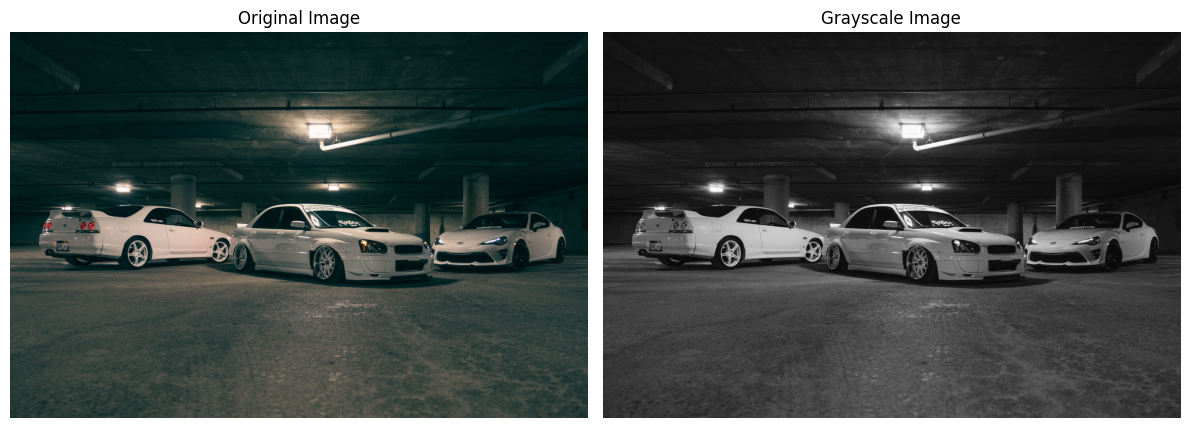

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
sift = cv2.SIFT_create()

keypoints, descriptors = sift.detectAndCompute(gray, None)

print("Number of keypoints detected:", len(keypoints))
print("Descriptor shape:", descriptors.shape if descriptors is not None else None)

Number of keypoints detected: 13520
Descriptor shape: (13520, 128)


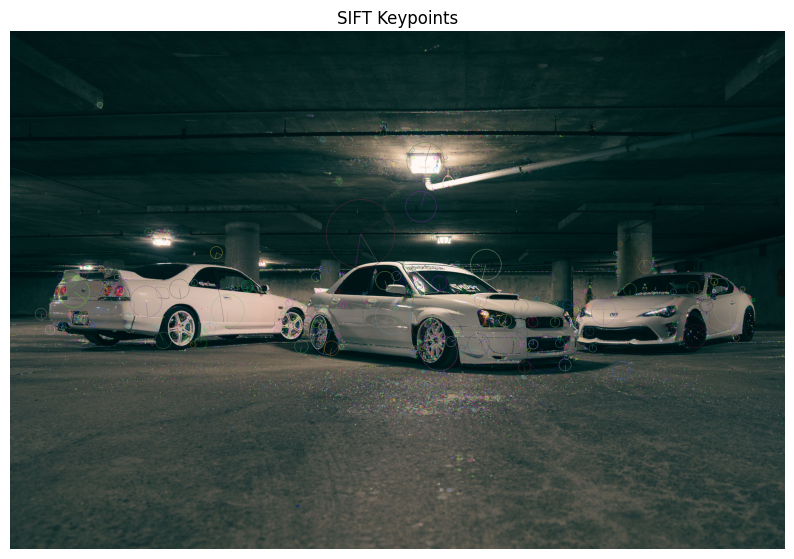

In [7]:
sift_image = cv2.drawKeypoints(
    img,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(sift_image, cv2.COLOR_BGR2RGB))
plt.title('SIFT Keypoints')
plt.axis('off')
plt.show()

In [8]:
hog_features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True
)

print("HOG feature extraction completed.")
print("HOG feature vector length:", len(hog_features))

HOG feature extraction completed.
HOG feature vector length: 6722532


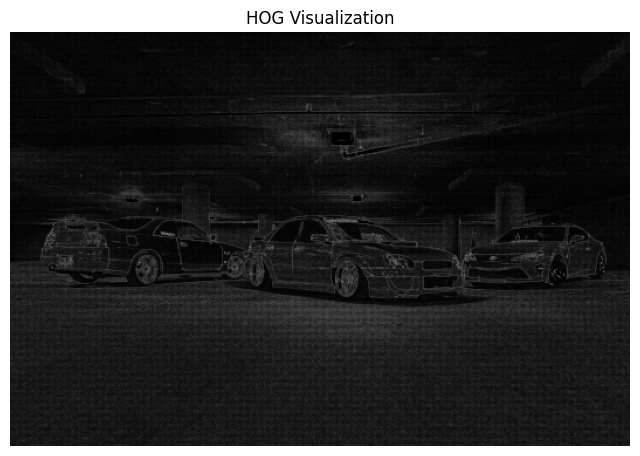

In [9]:
hog_image_rescaled = exposure.rescale_intensity(
    hog_image,
    in_range=(0, 10)
)

plt.figure(figsize=(8, 6))
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title('HOG Visualization')
plt.axis('off')
plt.show()

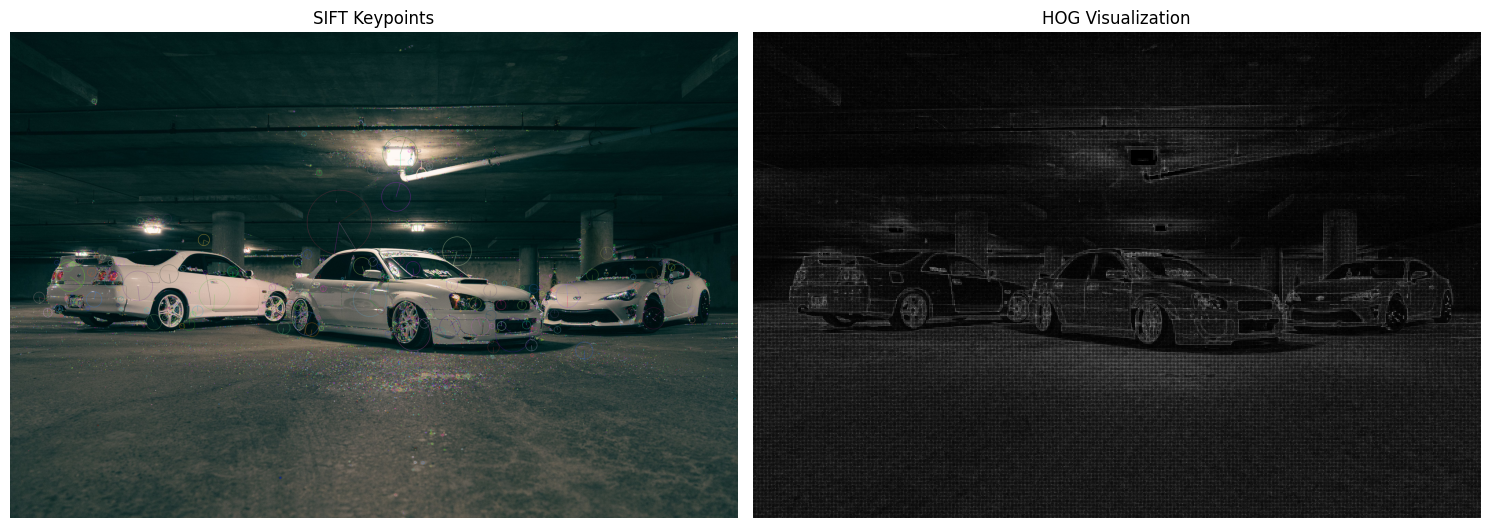

In [10]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(sift_image, cv2.COLOR_BGR2RGB))
plt.title('SIFT Keypoints')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title('HOG Visualization')
plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
image2_path = '/content/image2.jpg'

img2 = cv2.imread(image2_path)

if img2 is None:
    print("Error: Second image could not be loaded.")
else:
    print("Second image loaded successfully!")
    print("Image dimensions:", img2.shape)

Second image loaded successfully!
Image dimensions: (2832, 4240, 3)


In [12]:
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

In [13]:
keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)

print("Number of keypoints in Image 2:", len(keypoints2))
print("Descriptor shape:", descriptors2.shape if descriptors2 is not None else None)

Number of keypoints in Image 2: 9853
Descriptor shape: (9853, 128)


In [14]:
bf = cv2.BFMatcher()

matches = bf.knnMatch(
    descriptors,
    descriptors2,
    k=2
)

print("Total descriptor match pairs:", len(matches))

Total descriptor match pairs: 13520


In [15]:
good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Number of good matches:", len(good_matches))

Number of good matches: 588


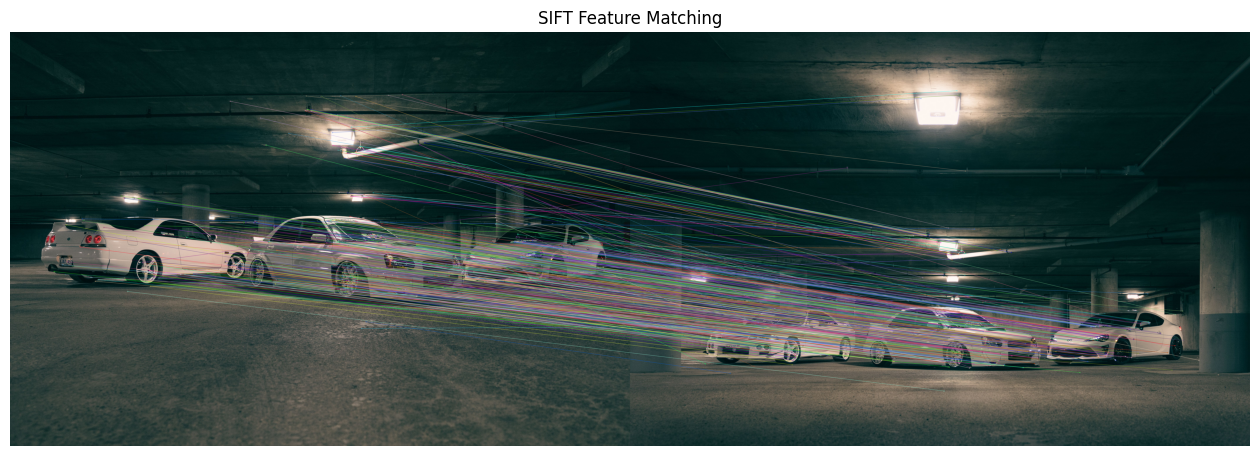

In [16]:
match_image = cv2.drawMatches(
    img,
    keypoints,
    img2,
    keypoints2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(match_image, cv2.COLOR_BGR2RGB))
plt.title('SIFT Feature Matching')
plt.axis('off')
plt.show()

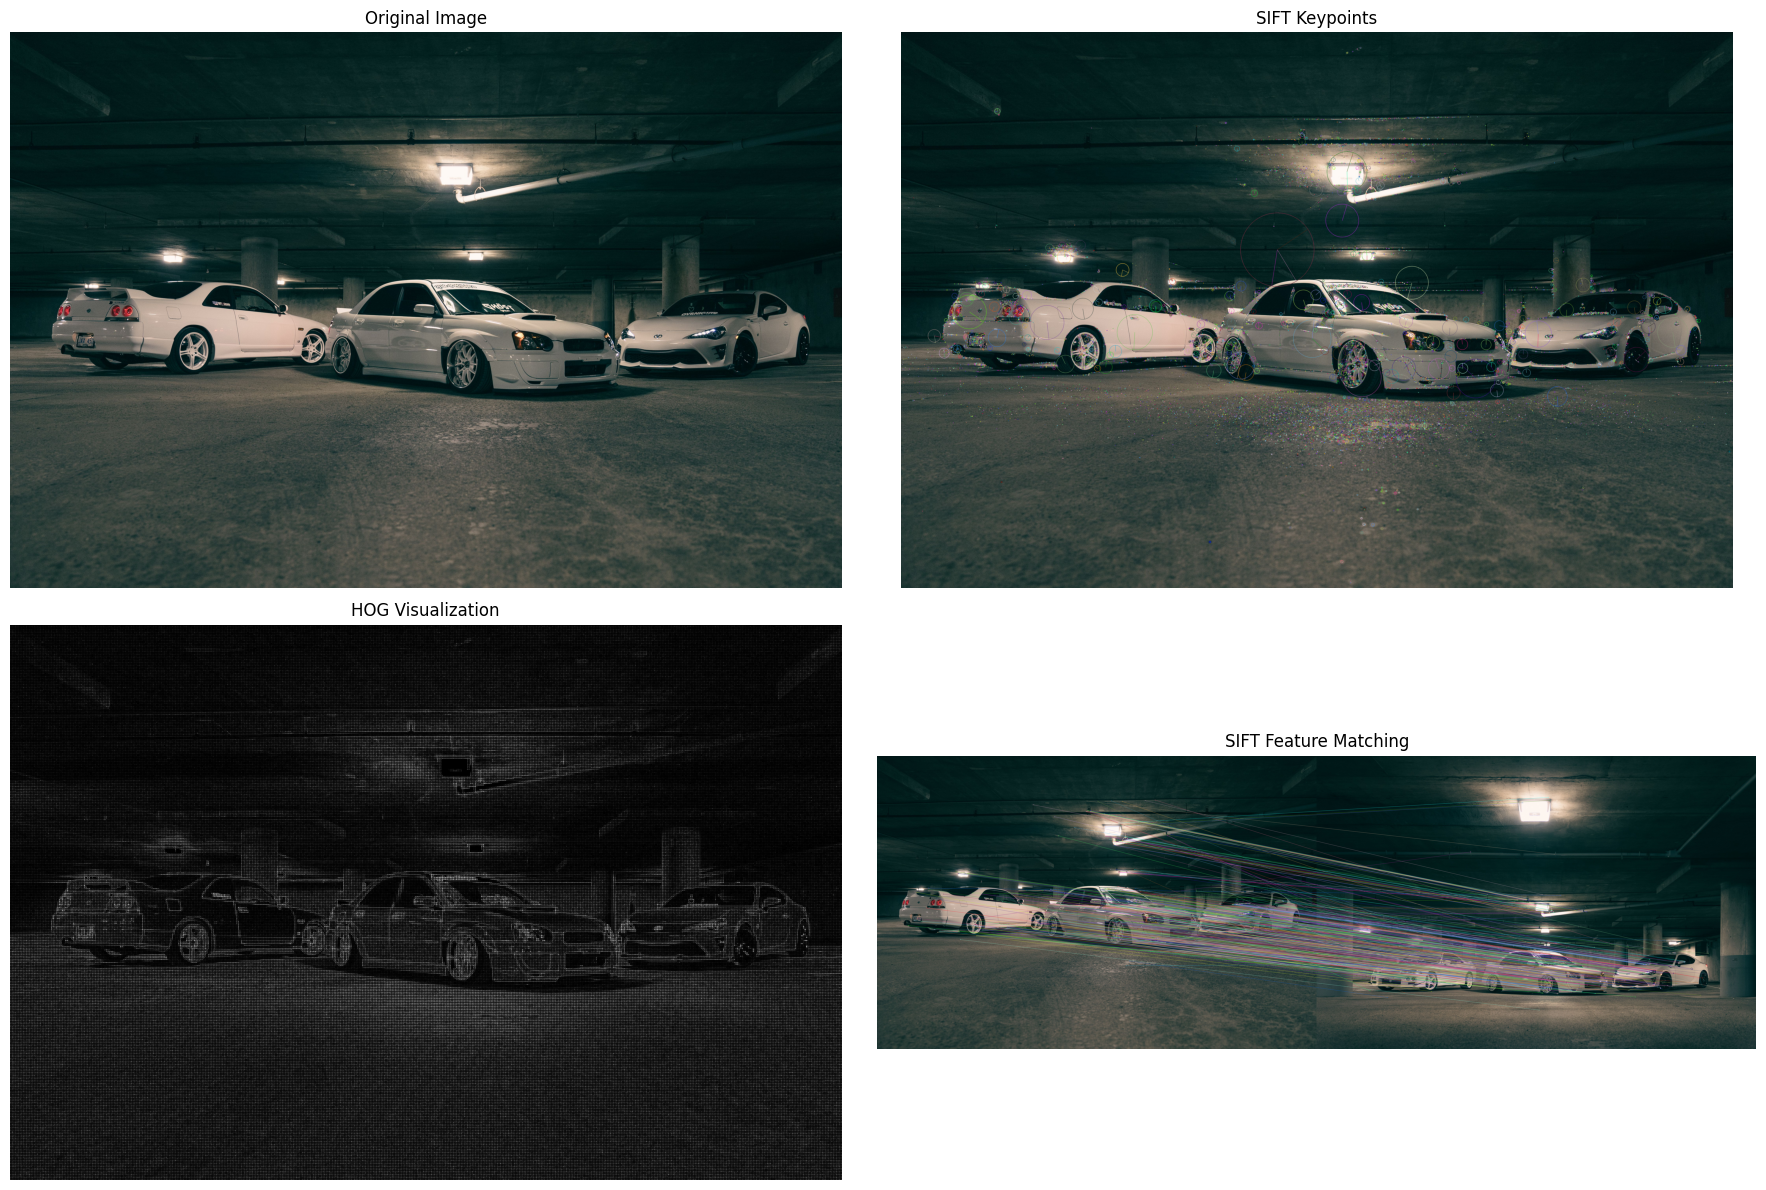

In [17]:
plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(sift_image, cv2.COLOR_BGR2RGB))
plt.title('SIFT Keypoints')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title('HOG Visualization')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(match_image, cv2.COLOR_BGR2RGB))
plt.title('SIFT Feature Matching')
plt.axis('off')

plt.tight_layout()
plt.show()

In [18]:
# Save practical results

cv2.imwrite('/content/original_image.png', img)
cv2.imwrite('/content/grayscale_image.png', gray)
cv2.imwrite('/content/sift_keypoints.png', sift_image)
cv2.imwrite('/content/hog_visualization.png', hog_image_rescaled)
cv2.imwrite('/content/sift_matching.png', match_image)

print("All resultant images saved successfully!")

All resultant images saved successfully!


Name - Alok Kumar Mavi

Section - B

Roll.no. 05

CU ID - CU240251681

# Lab Sheet 5 — Theory Questions and Answers

Ques 1. What is feature extraction, and why is it important in computer vision?

**Ans-** Feature extraction is the process of converting raw image data into meaningful and useful features that can represent important visual information. These features can then be used for tasks such as **object recognition, image matching, tracking, and classification**.

It is important because suitable features make an image easier for a computer vision system to analyze and recognize, while reducing the need to process the complete raw image.

---

Ques 2. Explain the working principle of Scale-Invariant Feature Transform (SIFT).

**Ans-** SIFT is a feature extraction technique that detects distinctive points in an image and generates descriptors for those points. It identifies important image regions across different scales and assigns an orientation to the detected features.

The resulting descriptors describe the local appearance around each keypoint, allowing corresponding features to be identified between images even when there are changes in **scale or rotation**. SIFT is therefore useful for image matching and object recognition.

---

Ques 3. What are keypoints and feature descriptors in image analysis?

**Ans-** **Keypoints** are distinctive locations or regions in an image that contain important visual information, such as corners, edges, or other recognizable structures.

**Feature descriptors** are numerical representations of the local information around these keypoints. They allow a computer vision system to compare features between images and determine whether corresponding points represent the same object or scene.

---

Ques 4. Explain the concept of Histogram of Oriented Gradients (HOG) and its significance.

**Ans-** Histogram of Oriented Gradients (HOG) is a feature extraction technique that represents an image by analyzing the **direction and magnitude of intensity gradients**.

The image is divided into small cells, gradient orientations are calculated within each cell, and these orientations are represented using histograms. Groups of cells are normalized using blocks to make the representation more robust.

HOG is significant because it captures the **shape, edges, and structural information** of objects, making it useful for object detection and recognition tasks.

---

Ques 5. Compare SIFT and HOG based on robustness, computational complexity, and practical applications.

**Ans-**

| SIFT                                                                                          | HOG                                                                                  |
| --------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------ |
| Detects distinctive keypoints and generates local descriptors.                                | Represents an image using local gradient orientations.                               |
| Highly robust to changes in scale and rotation.                                               | Primarily captures shape and edge information.                                       |
| Generally more computationally complex because it detects and describes individual keypoints. | Generally simpler when computing gradients and histograms over a fixed image region. |
| Useful for image matching, object recognition, and tracking.                                  | Commonly useful for object detection and shape-based recognition.                    |

Thus, SIFT is more suitable when **local feature matching and invariance** are important, whereas HOG is particularly useful when the **shape and edge structure** of an object are important.

---

Ques 6. Why is SIFT considered invariant to scale and rotation?

**Ans-** SIFT is considered scale-invariant because it detects features across different image scales, allowing the same feature to be recognized even when the object appears larger or smaller.

It is considered rotation-invariant because an orientation is assigned to each detected keypoint. The feature descriptor is then constructed relative to this orientation, allowing the same feature to be recognized even when the image is rotated.

---

Ques 7. Mention three real-world applications where HOG descriptors are commonly used.

**Ans-**

1. **Pedestrian detection** — detecting people in images or video.
2. **Object detection** — identifying objects based on their shape and edge structure.
3. **Surveillance and tracking systems** — detecting and tracking objects or people in video frames.

---

Ques 8. Why is feature extraction performed before image classification or object detection?

**Ans-** Feature extraction is performed before classification or object detection to convert raw image data into a more **compact and meaningful representation**.

Instead of directly processing every pixel, the system can use important characteristics such as edges, shapes, keypoints, and local patterns. This makes subsequent tasks such as classification, recognition, and detection more effective and computationally manageable.

---

Ques 9. What are the advantages and limitations of handcrafted feature descriptors compared to deep learning-based feature extraction?

**Ans-** Handcrafted descriptors such as SIFT and HOG are designed using predefined mathematical techniques.

**Advantages:**

* They are interpretable and based on well-defined image properties.
* They can work effectively with relatively small datasets.
* They can be computationally practical for specific traditional computer vision tasks.

**Limitations:**

* Their performance depends on manually designed features and parameters.
* They may not represent complex visual patterns as effectively as deep learning methods.
* Deep learning methods can learn useful features automatically from large datasets, while handcrafted methods require the feature representation to be designed beforehand.

---

Ques 10. How do feature extraction techniques contribute to image matching, face recognition, and object detection systems?

**Ans-** Feature extraction techniques provide meaningful representations of important image characteristics.

In **image matching**, descriptors such as SIFT can be compared to find corresponding features between two images.

In **face recognition**, extracted features can represent distinctive facial patterns that can be compared between faces.

In **object detection**, features such as edges, shapes, gradients, and local structures help identify and distinguish objects from their surroundings.

Therefore, feature extraction provides the important visual information required by computer vision systems for **matching, recognition, classification, and detection**.
